# CDR ensemble visualization

Two views of a conformational ensemble of antibody CDR loops:

1. **Structural overlay** — every member's loops superposed on a shared framework, drawn
   with py3Dmol and zoomed on the paratope.
2. **Conformation landscape** — the same loops projected to two dimensions, with a third
   quantity raised over the plane and smoothed into a surface.

Runs on CPU in under a minute. No GPU, no model weights, no predictions required.

The ensemble used here is **PDB 9KFW**, a 20-model solution-NMR structure of an
anti-OX40 nanobody. NMR depositions carry an experimentally determined conformational
ensemble in a single entry, so the loop diversity shown below is measured rather than
predicted — which makes it a good reference for what these plots look like when the
underlying spread is real.

In the main pipeline (`colab_boltz_cdr.ipynb`) the same two functions are applied to
Boltz-2 predictions instead, with model confidence on the third axis.

In [2]:
import sys, pathlib
root = pathlib.Path.cwd()
if not (root / "src").exists():
    root = root.parent                      # running from notebooks/
sys.path.insert(0, str(root / "src"))

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 84        # keeps the committed outputs a sensible size

from boltz_cdr.pdb_io import fetch_cif, load_models
from boltz_cdr.cdr import annotate_vhh
from boltz_cdr.visualize import (
    superpose_cdr_ensemble, pairwise_rmsd,
    conformation_landscape, plot_landscape, ensemble_view,
)
print("boltz_cdr imported from", (root / "src").name + "/")

boltz_cdr imported from src/


## The ensemble

`load_models` reads every model of a multi-model file. The CDRs are then annotated from
sequence by the IMGT annotator, exactly as they would be for a prediction.

In [3]:
PDB_ID = "9KFW"          # 20-model NMR structure of an anti-OX40 nanobody

models = load_models(fetch_cif(PDB_ID, root / "data" / "pdb"))
annotation = annotate_vhh(models[0].seq)

print(f"{PDB_ID}: {len(models)} models, {models[0].n_res} residues, chain {models[0].chain_id}")
print(annotation.summary())

9KFW: 20 models, 130 residues, chain A
CDR1[8]=GFTLDYYA  CDR2[8]=ISSSGGST  CDR3[23]=AAVDDVGTTVQAMAVHEPYEYDY


## How much do the loops actually move?

Superposing on the antibody framework removes rigid-body motion, so the spread that
remains is loop conformation alone.

156 backbone atoms over 39 CDR residues
pairwise CDR RMSD after framework superposition: mean 3.23 A, max 5.62 A


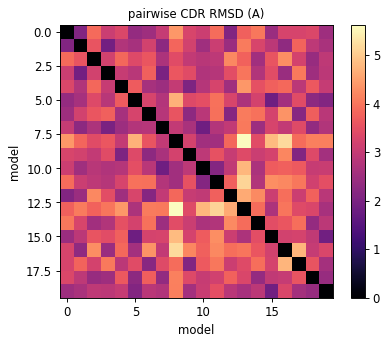

In [4]:
ensemble = superpose_cdr_ensemble(models, annotation)
distance = pairwise_rmsd(ensemble)
off_diagonal = distance[~np.eye(len(distance), dtype=bool)]

print(f"{ensemble.cdr_coords.shape[1]} backbone atoms over "
      f"{len(ensemble.residue_indices)} CDR residues")
print(f"pairwise CDR RMSD after framework superposition: "
      f"mean {off_diagonal.mean():.2f} A, max {distance.max():.2f} A")

fig, ax = plt.subplots(figsize=(5.2, 4.2))
image = ax.imshow(distance, cmap="magma")
ax.set_xlabel("model"); ax.set_ylabel("model")
ax.set_title("pairwise CDR RMSD (A)", fontsize=10)
fig.colorbar(image, ax=ax)
plt.tight_layout(); plt.show()

## 1 · Structural overlay

The framework is drawn once, muted; each model contributes only its CDR loops. The camera
is zoomed on the paratope.

**Color runs red to purple along an ordering of the models by structural similarity**, so
position in the spectrum is itself a coordinate through conformational space: loops of a
similar shape take similar colors, and two models at opposite ends of the rainbow are the
two most different conformations in the ensemble. The ordering comes from hierarchical
clustering of the pairwise CDR RMSD matrix with optimal leaf ordering, which uses the
whole distance matrix rather than a single projected axis. Set `color_by="value"` to color
by a metric instead, or `color_by="index"` for plain list position.

Drag to rotate. The controls below the viewer are live:

- **side chains** — show or hide side-chain atoms. They make the contacts but clutter an
  overlay of twenty models, so this is a toggle rather than a fixed choice.
- **color side chains by element** — side-chain carbon keeps the model's own color while
  nitrogen, oxygen and sulfur take their conventional colors, so the polar and charged
  atoms that would form interface contacts stay identifiable without losing track of
  which model a side chain belongs to.
- **framework / antigen** — hide the shared context and leave only the loops.
- **the legend** — one checkbox per model, labeled with its PDB model number, so
  individual conformations can be isolated or removed. `show all` and `hide all` act on
  every model at once.

The controls are plain JavaScript rather than ipywidgets, so they keep working in this
saved notebook without a running kernel. GitHub's notebook preview strips scripts and
will show this cell as blank; Colab, Jupyter and nbviewer render it.

In [5]:
view = ensemble_view(
    models,
    annotation,
    width=820,
    height=520,
    side_chains=True,                    # start with side chains drawn
    color_side_chains_by_element=True,   # N blue, O red, S yellow; C per model
)
view.show()

<EnsembleView: 20 members>

## 2 · Conformation landscape

The loops are projected to two dimensions by PCA — the axes are the dominant modes of
loop displacement, and the labels report how much of the ensemble's variance the two
components capture.

The third axis needs a per-structure quantity. With predicted structures that would be
model confidence or DockQ; an NMR ensemble has neither, so this uses the
**solvent-accessible surface area of the CDR loops**, a genuine conformational property
that distinguishes compact paratope conformations from extended ones.

Each point carries both readings at once: it is **filled** with the color that model has in
the 3D overlay, and **ringed** with its value on the surface's own color scale. The fill
says which structure it is — find a fill color here, then isolate that model in the
viewer's legend above — and the ring says how the structure scores, so a ring that matches
the surface beneath it is a point the smoothing reproduces. A white halo separates the two
so a ring whose value matches that surface stays visible.

The surface is a Gaussian kernel average, not an interpolant: it cannot exceed the range
of the observed values, and it is masked wherever no model lies close enough to support
it. The models themselves are drawn on top, so the evidence behind any feature is visible.

CDR solvent-accessible surface: 2470-2960 A^2


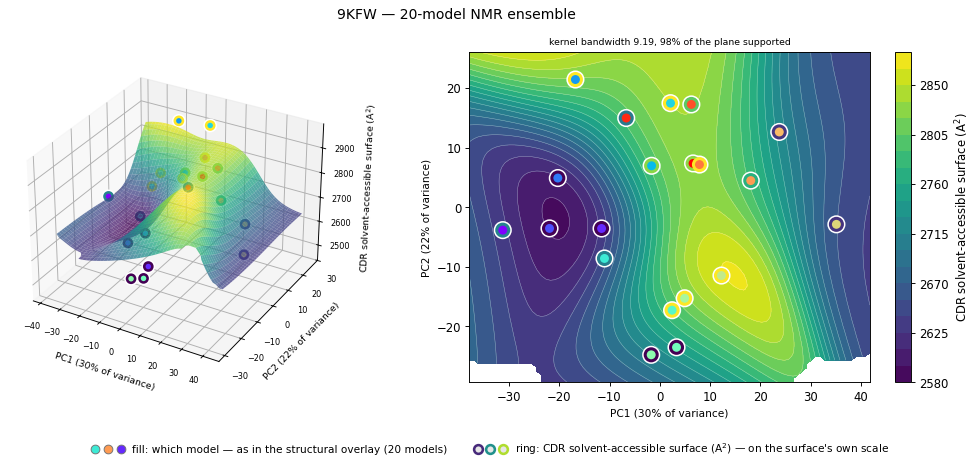

PC1+PC2 capture 53% of the variance
kernel bandwidth 9.19; 98% of the plane supported


In [6]:
from boltz_cdr.metrics.interface import sasa

cdr_atoms = models[0].atom_mask_for_residues(annotation.all_indices)
paratope_sasa = np.array([
    sasa(m.coords, m.atom_elements, n_points=96)[cdr_atoms].sum() for m in models
])
print(f"CDR solvent-accessible surface: {paratope_sasa.min():.0f}"
      f"-{paratope_sasa.max():.0f} A^2")

landscape, projection, coords = conformation_landscape(
    models, annotation, paratope_sasa, method="pca"
)
fig, _ = plot_landscape(
    landscape, projection,
    value_label="CDR solvent-accessible surface (A$^2$)",
    title=f"{PDB_ID} — {len(models)}-model NMR ensemble",
    point_colors=view.colors,     # same color each model has in the 3D overlay
)
plt.show()

print(f"PC1+PC2 capture {projection.explained_variance.sum():.0%} of the variance")
print(f"kernel bandwidth {landscape.bandwidth:.2f}; "
      f"{landscape.coverage:.0%} of the plane supported")

### The same plane, a different quantity

Any per-structure value can be raised over the same projection. Here it is each model's
deviation from the ensemble average conformation, which shows where the consensus
structure sits and how far the outliers are from it.

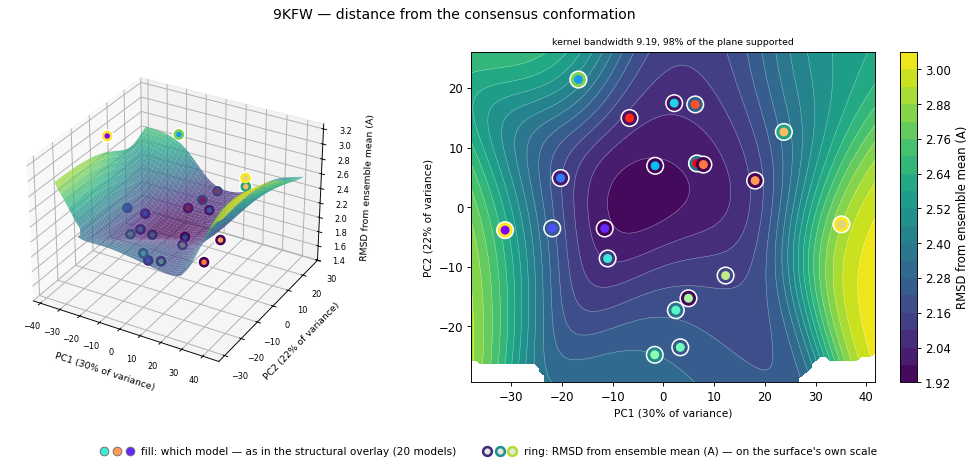

In [7]:
mean_conformation = ensemble.cdr_coords.mean(axis=0)
deviation = np.sqrt(
    ((ensemble.cdr_coords - mean_conformation) ** 2).sum(-1).mean(-1)
)

landscape2, projection2, _ = conformation_landscape(models, annotation, deviation)
fig, _ = plot_landscape(
    landscape2, projection2,
    value_label="RMSD from ensemble mean (A)",
    title=f"{PDB_ID} — distance from the consensus conformation",
    point_colors=view.colors,
)
plt.show()

## Applying this to sampled CDR conformations

Everything above takes any list of structures, so the same two views apply directly to the
alternate CDR conformations produced by the resampling arms. After `04_evaluate.py` has
written `results/analysis/samples.csv`:

```python
import pandas as pd
from boltz_cdr.pdb_io import load_complex
from boltz_cdr.yaml_io import ANTIBODY_CHAIN_ID, ANTIGEN_CHAIN_ID
from _common import load_targets

samples = pd.read_csv("results/analysis/samples.csv")
selected = samples[samples.target == "8QF4"].reset_index(drop=True)

target = load_targets(only=["8QF4"])[0]
structures = [
    load_complex(p, ANTIBODY_CHAIN_ID, ANTIGEN_CHAIN_ID) for p in selected["path"]
]
annotation = target.annotation_for(structures[0].antibody.seq)

# Loops colored by structural similarity, so the spectrum orders the sampled
# conformations; the legend labels each by the file it was predicted into.
view = ensemble_view(structures, annotation, values=selected["conf_iptm"].to_numpy())
view.show()

# Confidence over conformational space, keyed to the overlay by the point rings.
landscape, projection, _ = conformation_landscape(
    structures, annotation, selected["conf_iptm"].to_numpy()
)
plot_landscape(
    landscape, projection, value_label="ipTM", point_colors=view.colors,
)
```

Swapping `conf_iptm` for `dockq` puts true accuracy over the same plane. The two surfaces
side by side are the scorer question in visual form: where a confidence peak sits over a
DockQ trough, the model is confidently wrong about that region of conformational space.

Predicted complexes carry an antigen, so `ensemble_view` draws it as context and
`align_on="antigen"` becomes available — superposing on the target rather than the
framework, which puts rigid-body placement of the binder back into the picture instead of
removing it.

Complexes carry an antigen, so `ensemble_view` draws it as context and
`align_on="antigen"` becomes available — superposing on the target instead of the
framework, which puts rigid-body placement of the binder back into the picture rather
than removing it.